In [ ]:
# =============================================================================
# 1. ENVIRONMENT SETUP & MODULE IMPORTS
# =============================================================================
"""
Initialize the analysis environment by loading essential modules and setting up
the Python path to access custom analysis functions.
"""

# Enable automatic reloading of modules for interactive development
%load_ext autoreload
%autoreload 2

# Import essential system modules
import sys
from pathlib import Path

# Define the path to custom analysis modules
# Note: Update this path to match your local installation
MODULE_PATH = Path("/root/capsule/src/aind_dft_ephys_analysis")

# Add module path to system path for importing custom functions
if str(MODULE_PATH) not in sys.path:
    sys.path.insert(0, str(MODULE_PATH))

print(f"✅ Analysis modules loaded from: {MODULE_PATH}")
print("🔄 Auto-reload enabled for interactive development")

In [ ]:
# ALM recordings — sessions of interest
sessions = [
    "ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38",
    "ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35",
    "ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43",
    "ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45",
    "ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51",
    "ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13"
]


In [ ]:
# =============================================================================
# Build CD zarrs for the listed sessions
# =============================================================================
from pathlib import Path

from ephys_dimension_reduction_CD_pipeline import build_cd_dataset

psth_root     = Path("/root/capsule/scratch/psth_results")
behavior_root = Path("/root/capsule/scratch/behavior_summary")
cd_root       = Path("/root/capsule/scratch/CD_results")

# CD configuration
align                  = "go_cue"
binsize                = "0.1"
brain_regions_groups   = [[]]                    # [[]] => all units (RG_ALL)
time_windows           = [(-1, 0)]           # CD-fitting window(s)
#trial_types            = ("right_choice_trials", "left_choice_trials")
trial_types            = ("switch_LR_trials", "switch_RL_trials")
min_units_num          = 30
projection_time_window = None                    # None => full PSTH time axis
two_fold_cv            = True
norm_mode              = "divide_sqrtN"
random_state           = 0
overwrite              = True
zscore_units           = True

failed = build_cd_dataset(
    sessions=sessions,
    psth_root=psth_root,
    behavior_root=behavior_root,
    cd_root=cd_root,
    metadata=None,                               # None => no region filtering
    binsize=binsize,
    align=align,
    brain_regions_groups=brain_regions_groups,
    time_windows=time_windows,
    trial_types=trial_types,
    min_units_num=min_units_num,
    projection_time_window=projection_time_window,
    two_fold_cv=two_fold_cv,
    norm_mode=norm_mode,
    random_state=random_state,
    overwrite=overwrite,
    #zscore_units=zscore_units,
)


In [ ]:
# Per-session CD plots (one figure set per session)
import os

from ephys_dimension_reduction_CD_pipeline import (
    cd_save_path, load_cd_session, plot_cd_session, region_label,
)

cd_root = "/root/capsule/scratch/CD_results"
behavior_root = "/root/capsule/scratch/behavior_summary"

# Pick which region group + time-window combo to visualize per session.
# Must match one of the combos produced by the build cell.
viz_region_group = []            # [] => all units (matches RG_ALL files)
viz_time_window = (-1, 0)
distribution_window = (-1, 0)

# Optional: restrict each trial to its own [event_start, event_end] interval.
# Useful when align="trial_start" and ITI varies — averages then ignore
# samples after each trial's go_cue. Set to None to disable.
restrict_events = ("trial_start", "go_cue")

region_lbl, region_print = region_label(viz_region_group)
print(f"Viewing region: {region_lbl} ({region_print}), TW={viz_time_window}, align={align}")

for session in sessions:
    zpath = cd_save_path(
        cd_root, session, region_lbl, trial_types, viz_time_window, align=align,
    )
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not zpath.exists():
        print(f"[skip] CD zarr not found: {zpath}")
        continue
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV not found for {session}")
        continue

    print(f"\n=== Session: {session} ===\nFile: {zpath.name}")
    sess = load_cd_session(zpath, beh_csv)
    plot_cd_session(
        sess,
        distribution_window=distribution_window,
        restrict_events=restrict_events,   # None to disable
        restrict_align=align,              # CD axis time is relative to this
        xlim=(-15,15),
        #trial_types=["right_choice_trials", "left_choice_trials"],
        #trial_types=["right_rewarded_trials", "right_unrewarded_trials"],
        split='train',
        smooth_gauss=0.0,           # disable mean-trace smoothing
        smooth_moving_window=5,     # disable single-trial boxcar
        plot_single_trial=True,
        random_sample_trial_N=1,    # show 20 random trials per class
        #random_sample_seed=1, 
    )




Viewing region: RG_ALL (ALL), TW=(-1, 0), align=go_cue

=== Session: ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38 ===
File: CD_ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb


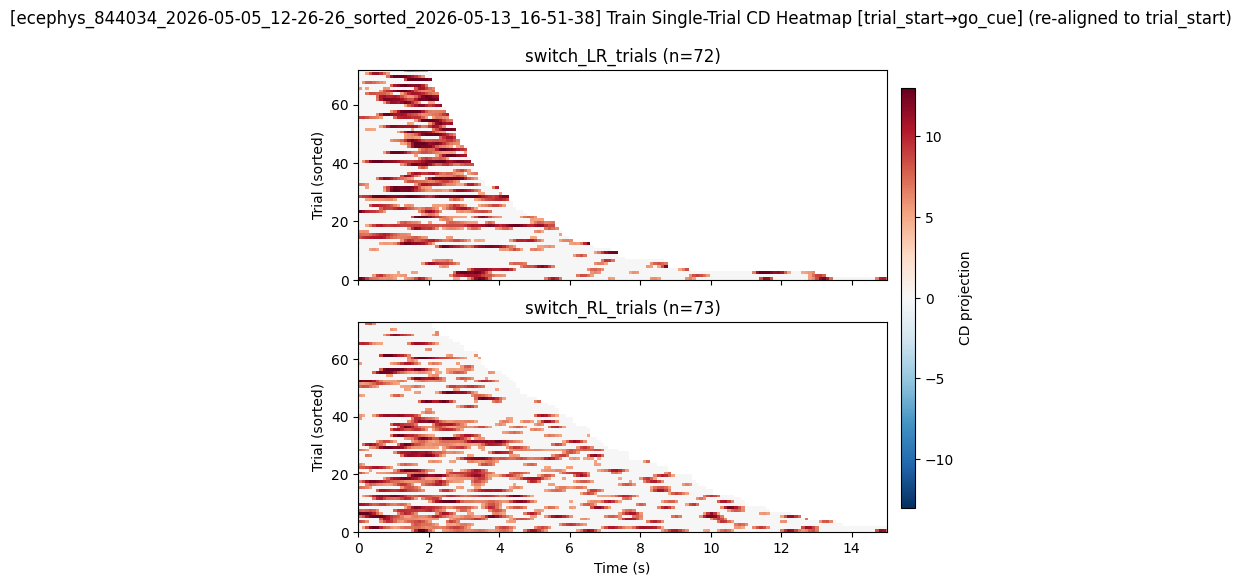

Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb


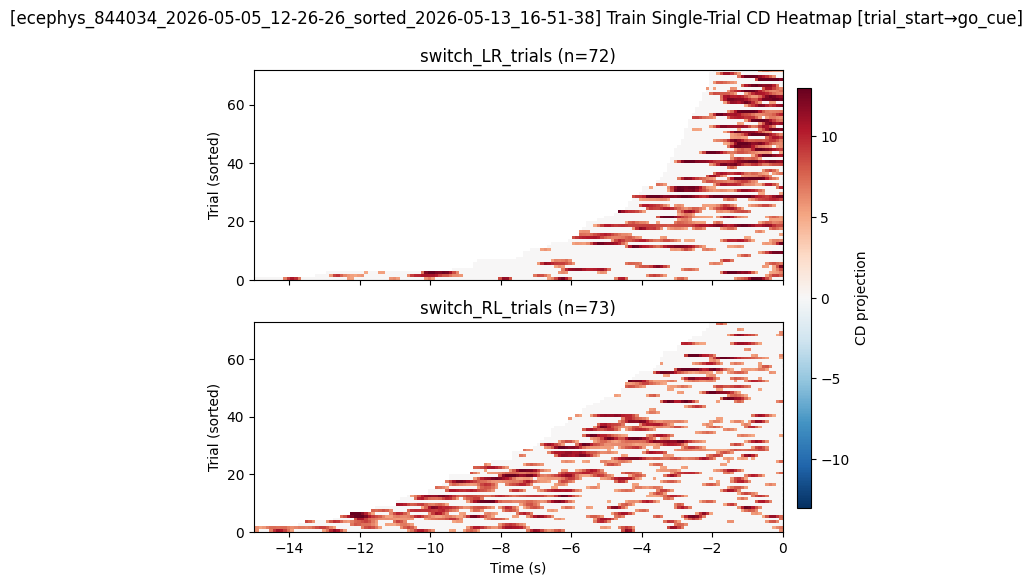


=== Session: ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35 ===
File: CD_ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb


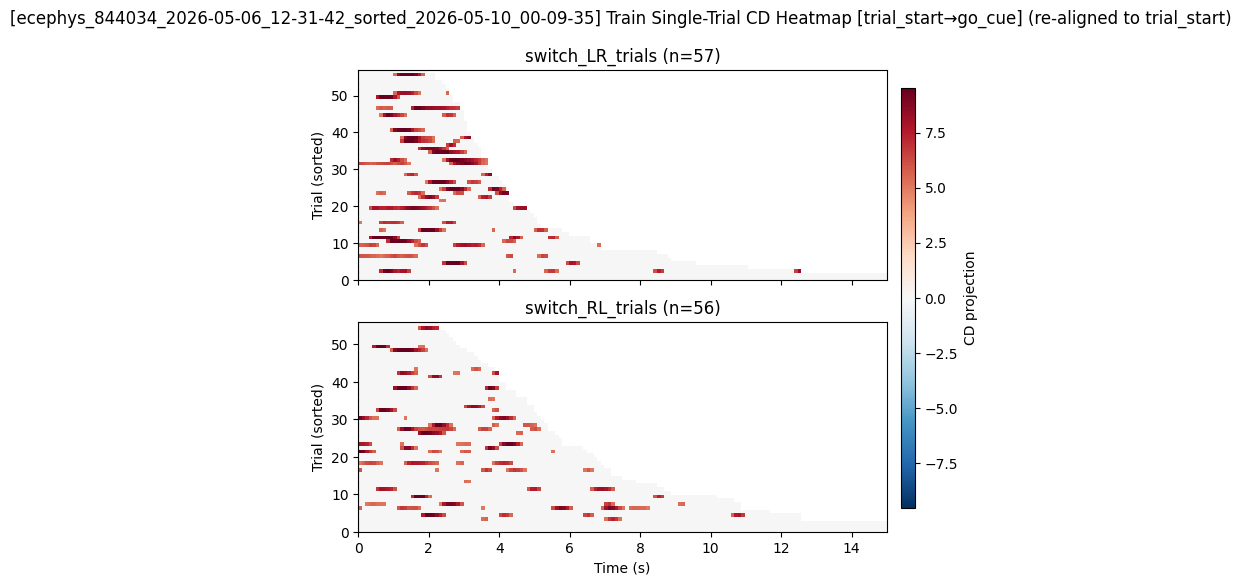

Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb


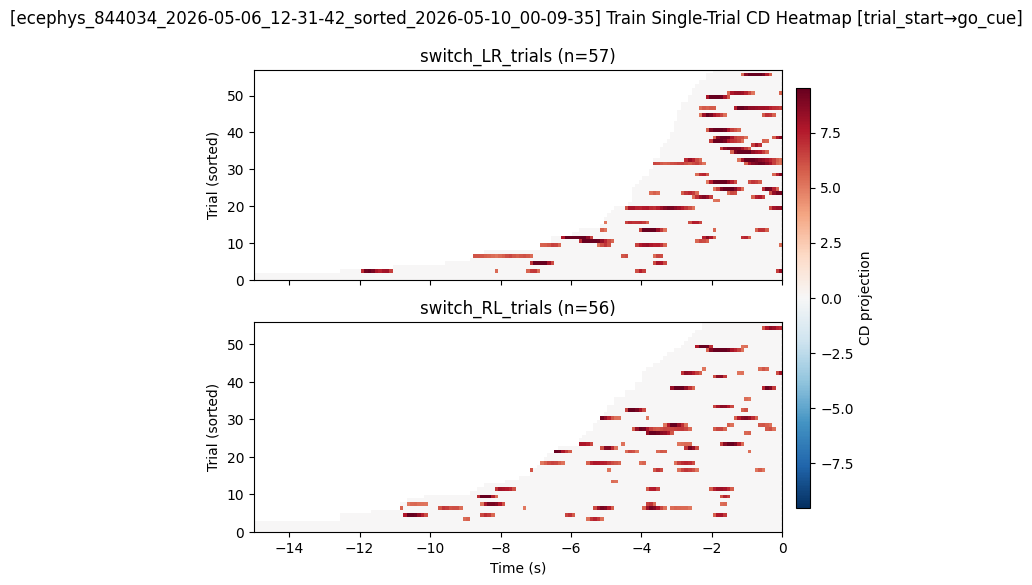


=== Session: ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43 ===
File: CD_ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb


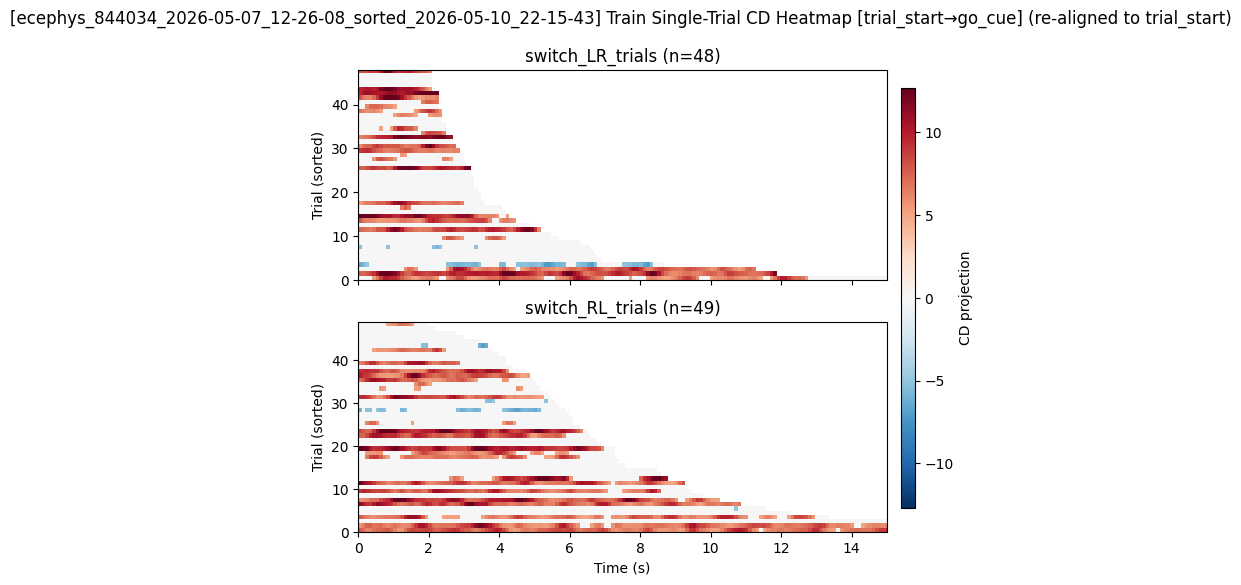

Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb


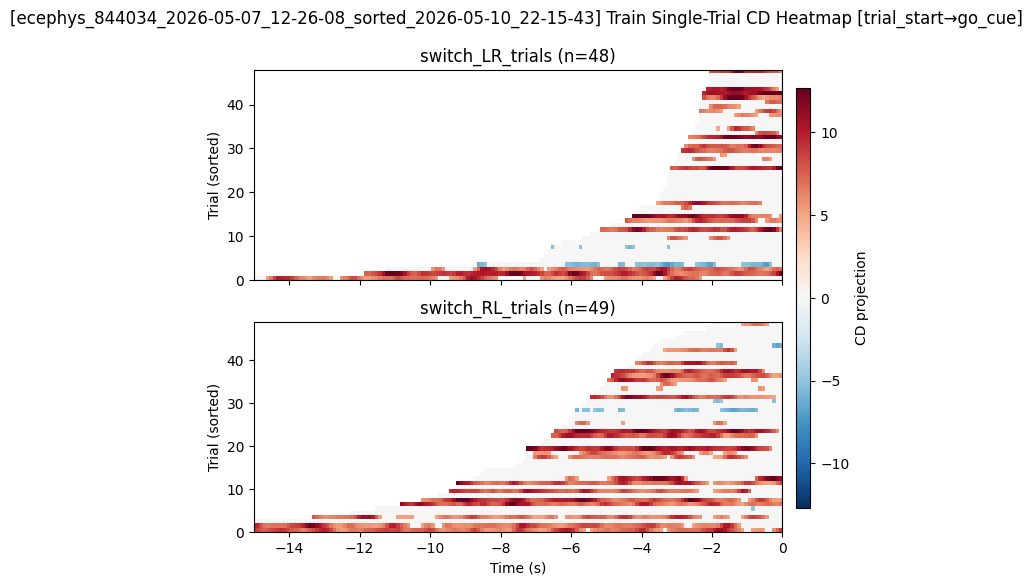


=== Session: ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45 ===
File: CD_ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb


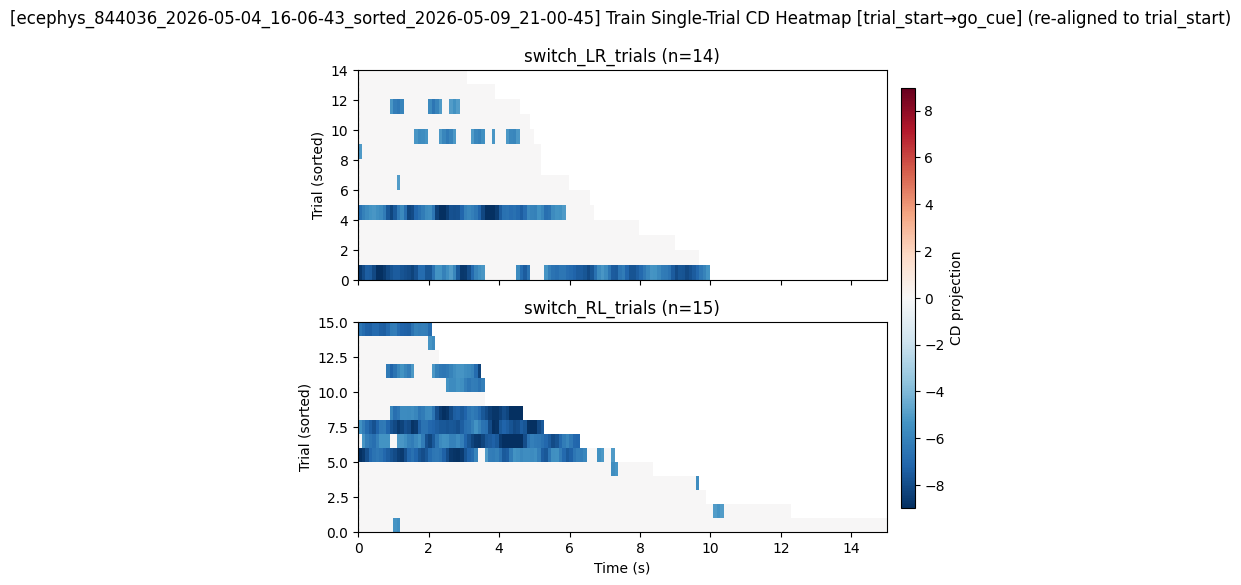

Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb


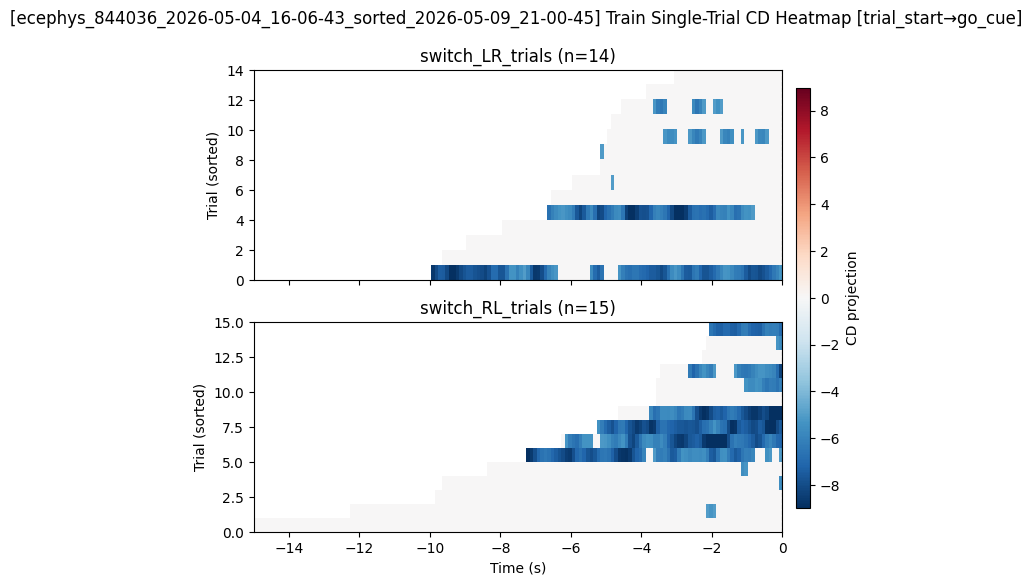


=== Session: ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51 ===
File: CD_ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb


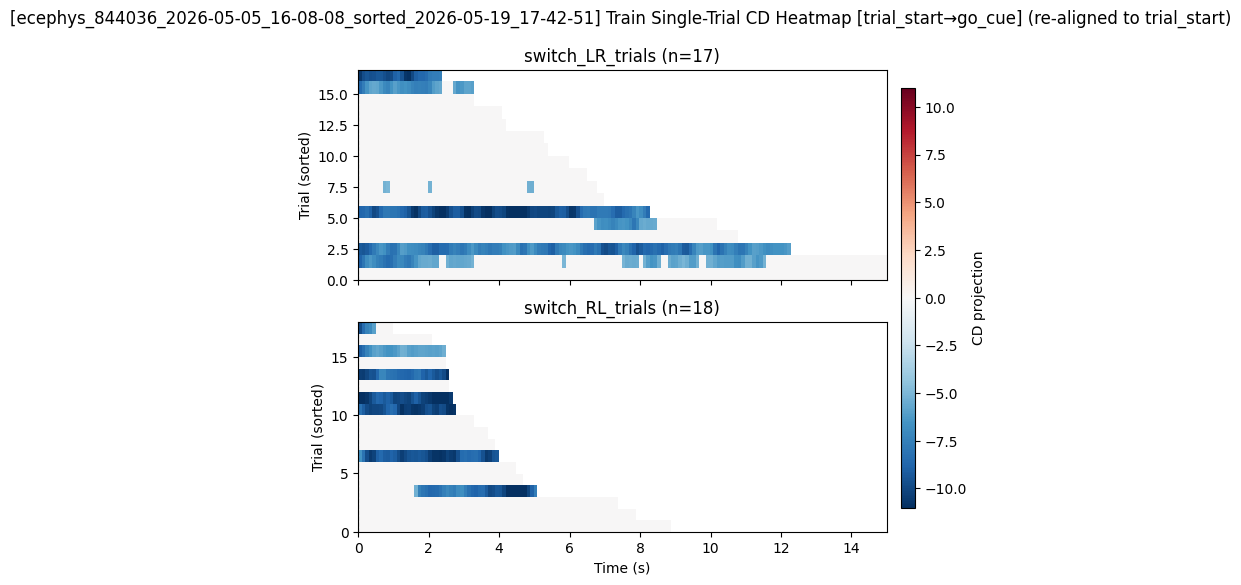

Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb


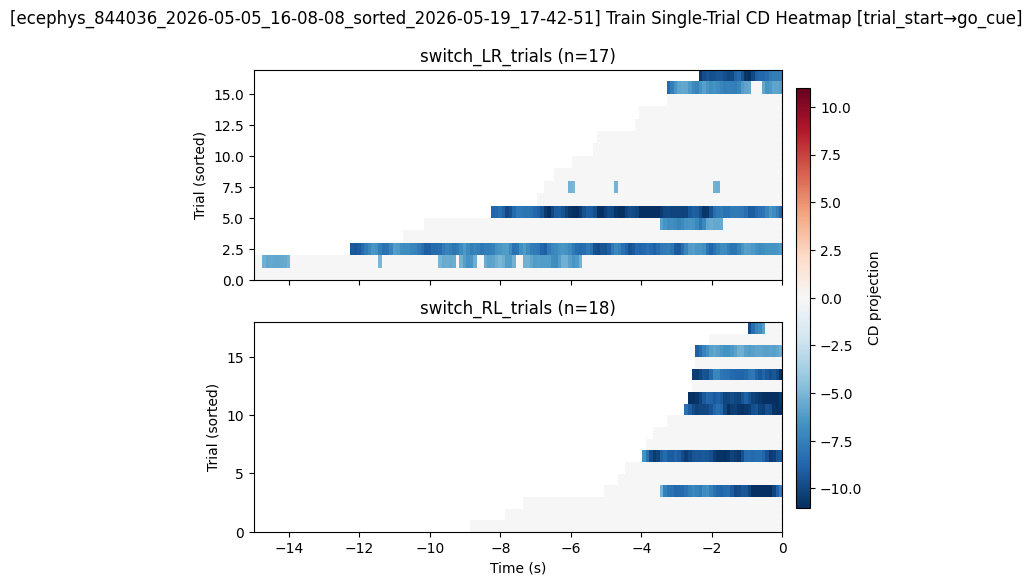


=== Session: ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13 ===
File: CD_ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13_RG_ALL_switch_LR_trials_switch_RL_trials_TW_-1_0_ALIGN_go_cue.zarr
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb


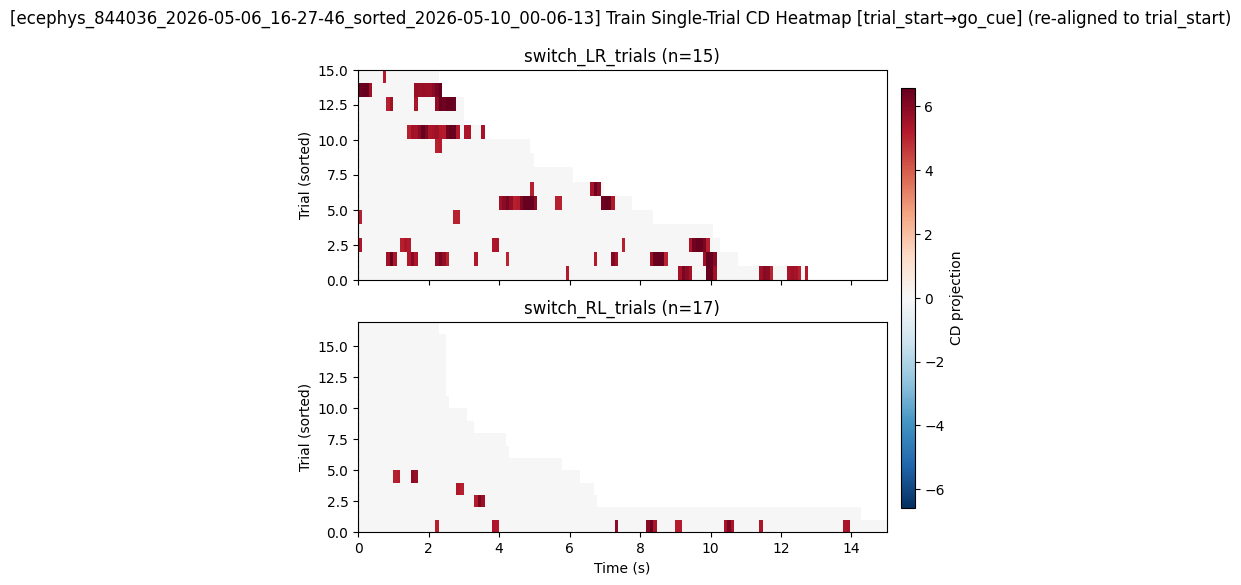

Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb


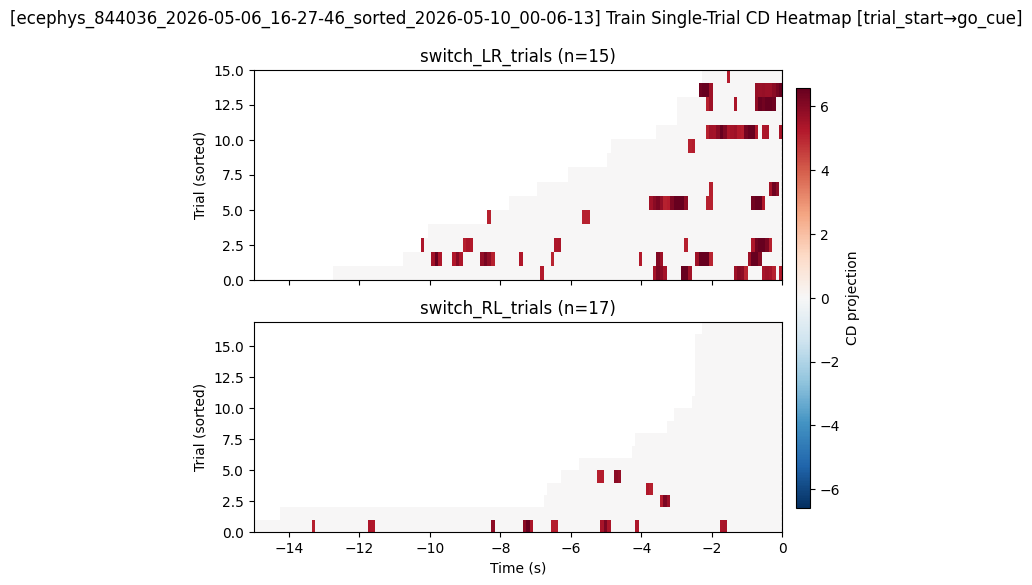

In [151]:
# =============================================================================
# Per-session SINGLE-TRIAL CD HEATMAPS
# Each panel = one class; rows = trials sorted by their averaged projection
# in `sort_window`. Mirrors plot_cd_session for trial selection and smoothing.
# =============================================================================
import os

from ephys_dimension_reduction_CD_pipeline import (
    cd_save_path, load_cd_session, plot_cd_session_heatmap, region_label,
)

cd_root = "/root/capsule/scratch/CD_results"
behavior_root = "/root/capsule/scratch/behavior_summary"

viz_region_group = []
viz_time_window = (-1, 0)
trial_types            = ("switch_LR_trials", "switch_RL_trials")
restrict_events = ("trial_start", "go_cue")

region_lbl, region_print = region_label(viz_region_group)
print(f"Viewing region: {region_lbl} ({region_print}), TW={viz_time_window}, align={align}")

for session in sessions:
    zpath = cd_save_path(
        cd_root, session, region_lbl, trial_types, viz_time_window, align=align,
    )
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not zpath.exists():
        print(f"[skip] CD zarr not found: {zpath}")
        continue
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV not found for {session}")
        continue

    print(f"\n=== Session: {session} ===\nFile: {zpath.name}")
    sess = load_cd_session(zpath, beh_csv)

    # Example 1: rewarded vs unrewarded right-choice trials, sort by mean
    # projection in the CD-fit window.
    plot_cd_session_heatmap(
        sess,
        #trial_types=["switch_LR_trials", "switch_RL_trials"],
        #trial_types=["right_choice_trials", "left_choice_trials"],
        smooth_gauss=0.1,
        sort_by="window_length",
        sort_window=(0, 15),
        xlim=(0,15),
        cmap="RdBu_r",
        symmetric_colorbar=True,
        restrict_events=restrict_events, 
        restrict_align="trial_start",   
        threshold=5,
    )

    plot_cd_session_heatmap(
        sess,
        #trial_types=["switch_LR_trials", "switch_RL_trials"],
        #trial_types=["right_choice_trials", "left_choice_trials"],
        smooth_gauss=0.1,
        sort_by="window_length",
        sort_window=(0, 15),
        xlim=(-15,0),
        cmap="RdBu_r",
        symmetric_colorbar=True,
        restrict_events=restrict_events, 
        restrict_align="go_cue",   
        threshold=5,
    )

    # Example 2: train split A vs B, sorted by peak time, with a random
    # 60-trial subsample per class for a cleaner view.
    # plot_cd_session_heatmap(
    #     sess,
    #     split="train",
    #     smooth_gauss=0.1,
    #     sort_by="peak_time",
    #     sort_window=(-1, 3),
    #     random_sample_trial_N=60,
    #     xlim=(-2, 5),
    # )


Viewing region: RG_ALL (ALL), TW=(-1, 0), align=go_cue

=== Session: ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38 ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-05_12-26-26.nwb

[ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38] right_choice_trials: 244/263 trials with bump in (-15, 0) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 406          -2.15         2.7        3.337589     2.261558      0.683431   0.645117     4.061515   -3.633123
     pos 569          -2.25         2.8        9.272162     3.647553      0.509218   0.323846     5.271086    4.640469


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


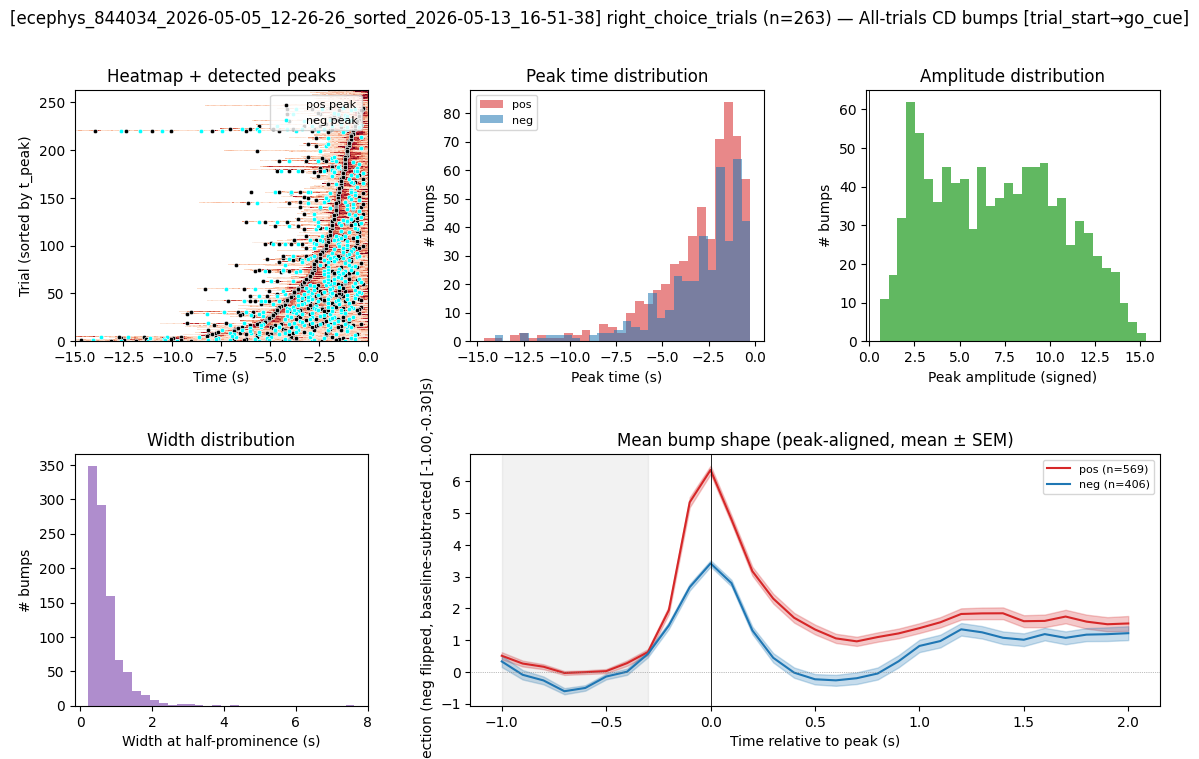

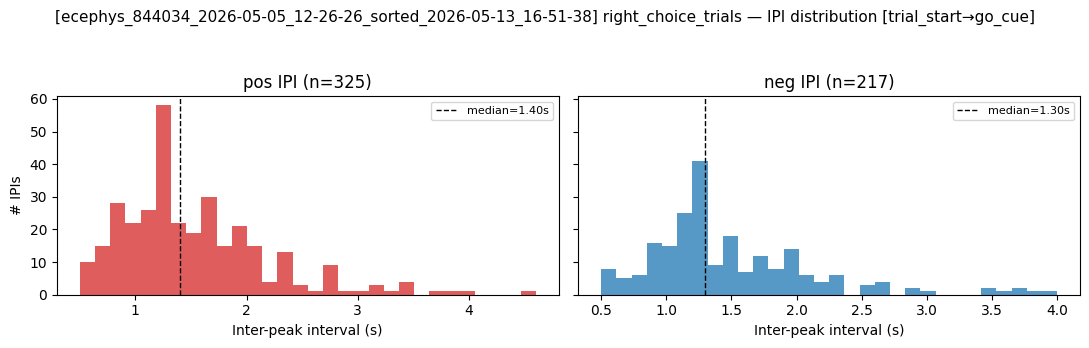


[ecephys_844034_2026-05-05_12-26-26_sorted_2026-05-13_16-51-38] left_choice_trials: 243/268 trials with bump in (-15, 0) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 468          -3.65         4.0        2.992519     1.855694      0.967314   0.933909     4.530584   -4.216728
     pos 666          -3.25         4.0        9.534560     4.908993      0.476116   0.310807     5.718870    4.338285


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


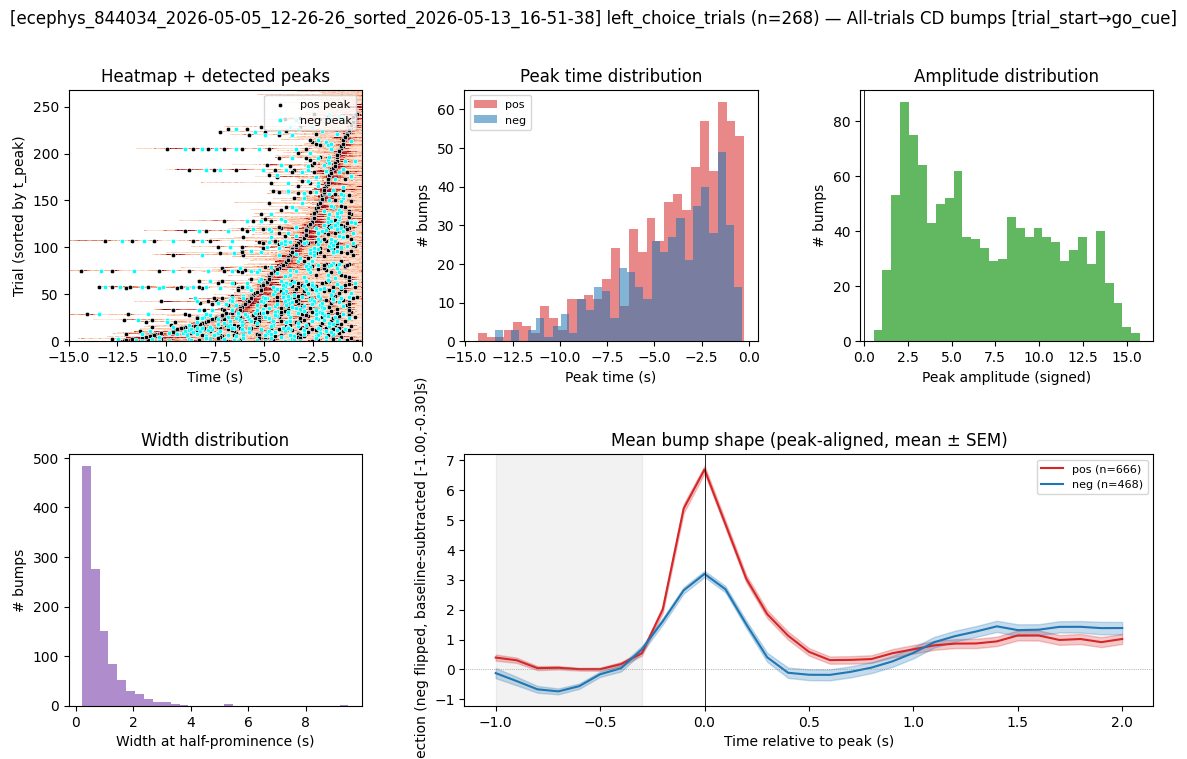

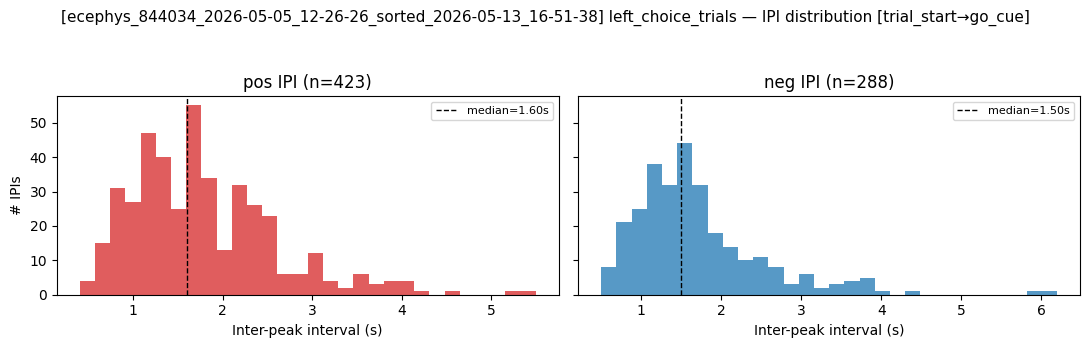


=== Session: ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35 ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-06_12-31-42.nwb

[ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35] right_choice_trials: 190/223 trials with bump in (-15, 0) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 211          -2.85         3.9        1.097562     0.871415      1.077424   1.076747     3.592154   -2.467876
     pos 354          -2.60         3.6        6.199009     3.465583      0.508886   0.263715     4.697470    3.103485


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


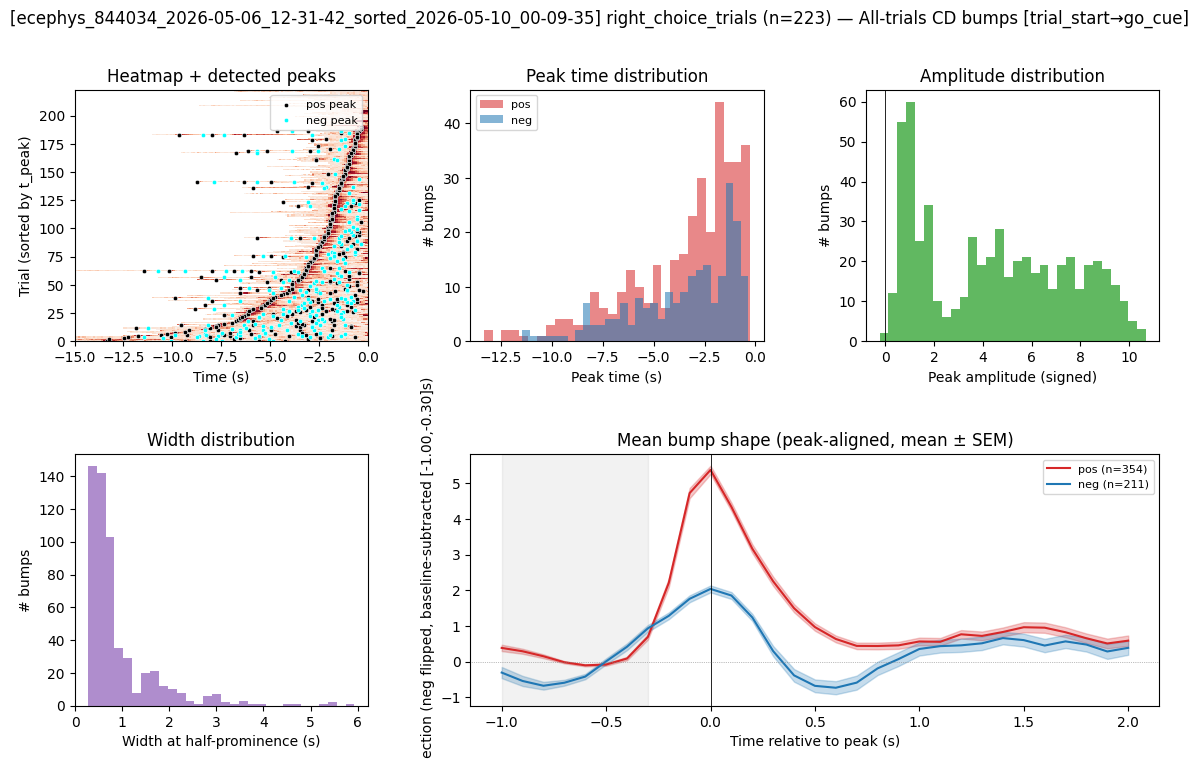

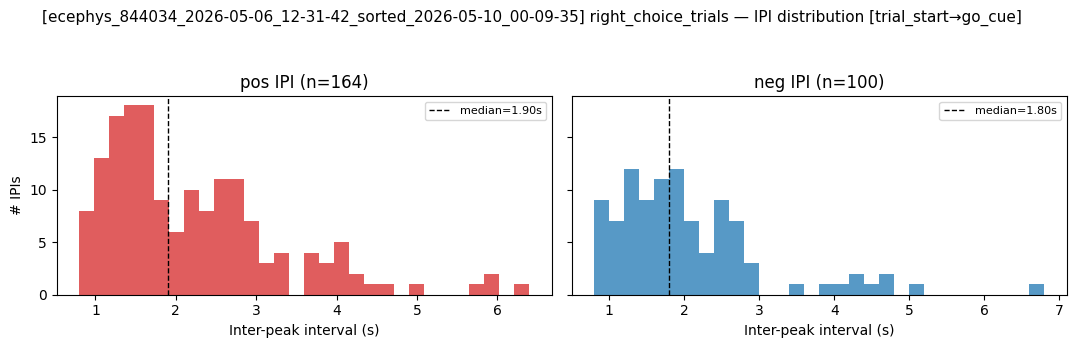


[ecephys_844034_2026-05-06_12-31-42_sorted_2026-05-10_00-09-35] left_choice_trials: 279/295 trials with bump in (-15, 0) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 438          -3.05         3.8        1.245005     0.860327      1.092168   0.941206     3.763215   -2.425477
     pos 659          -2.95         3.7        6.613408     3.415165      0.493759   0.260671     5.014121    3.126080


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


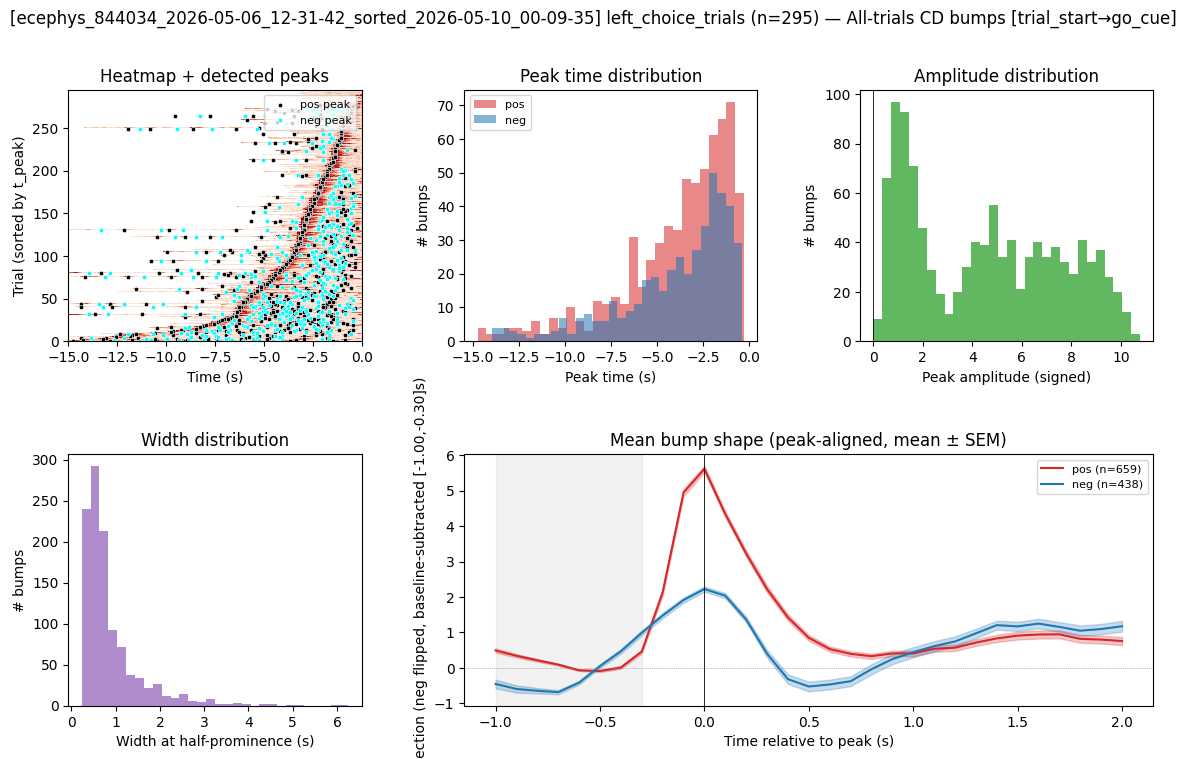

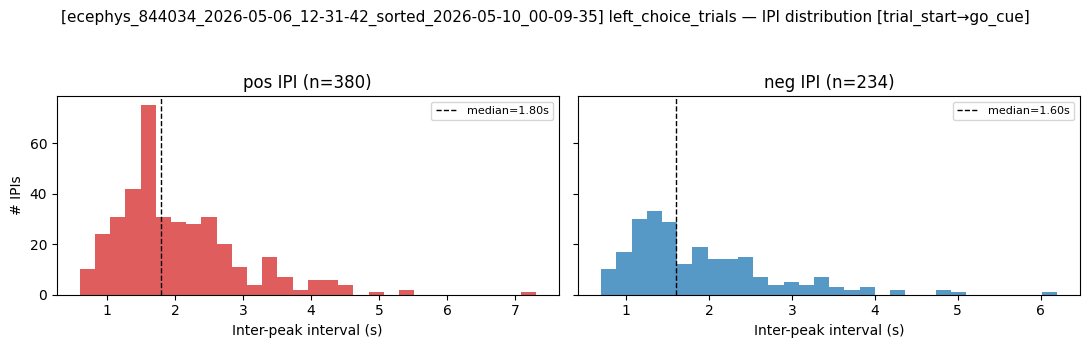


=== Session: ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43 ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844034_2026-05-07_12-26-08.nwb

[ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43] right_choice_trials: 198/206 trials with bump in (-15, 0) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 287          -2.35         2.7        2.799323     1.387262      0.710608   0.510931     3.075389   -2.782397
     pos 415          -2.55         2.7        6.660476     1.941839      0.536033   0.274119     3.657828    3.629414


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


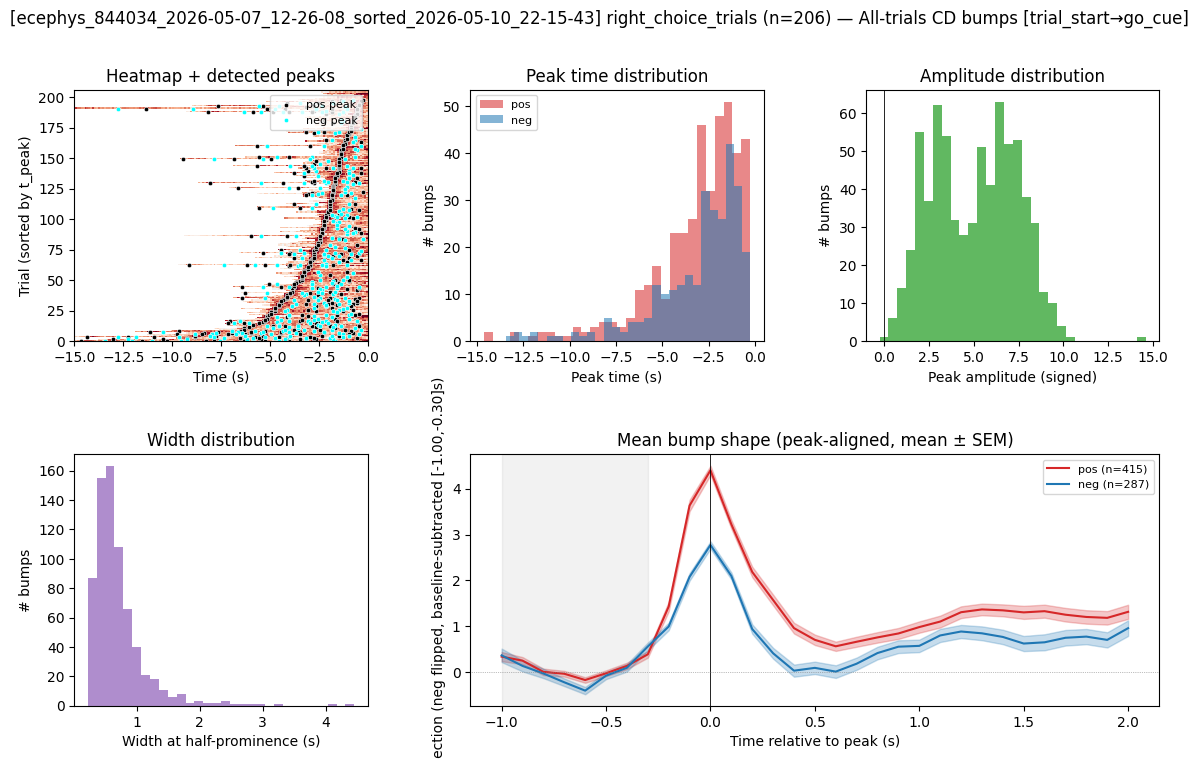

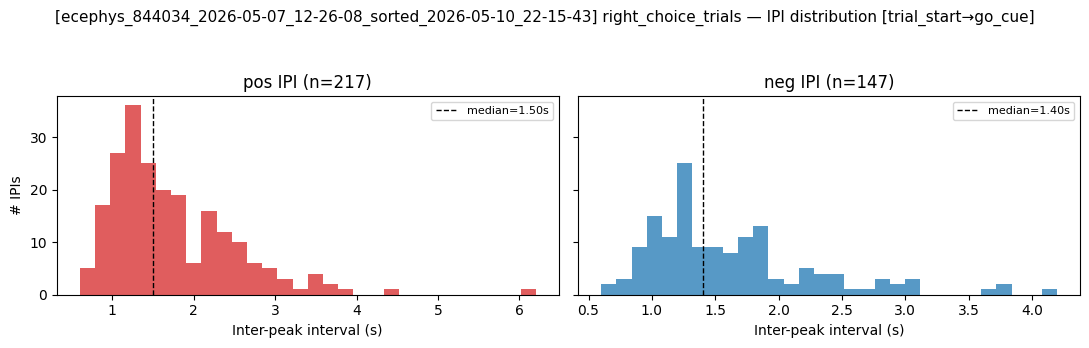


[ecephys_844034_2026-05-07_12-26-08_sorted_2026-05-10_22-15-43] left_choice_trials: 324/332 trials with bump in (-15, 0) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 618          -3.15         3.6        2.277145     1.342815      0.761764   0.511571     3.124906    -2.46773
     pos 853          -3.05         3.7        6.131524     1.873203      0.516513   0.306346     3.712849     3.12208


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


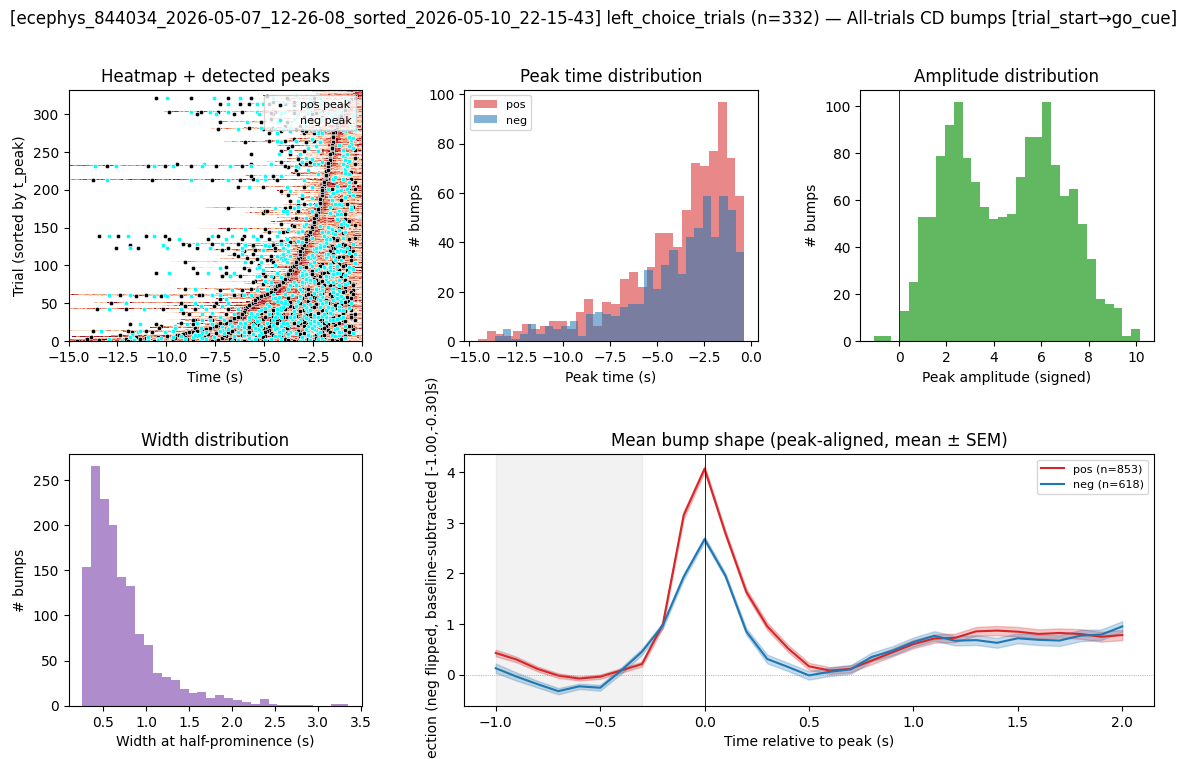

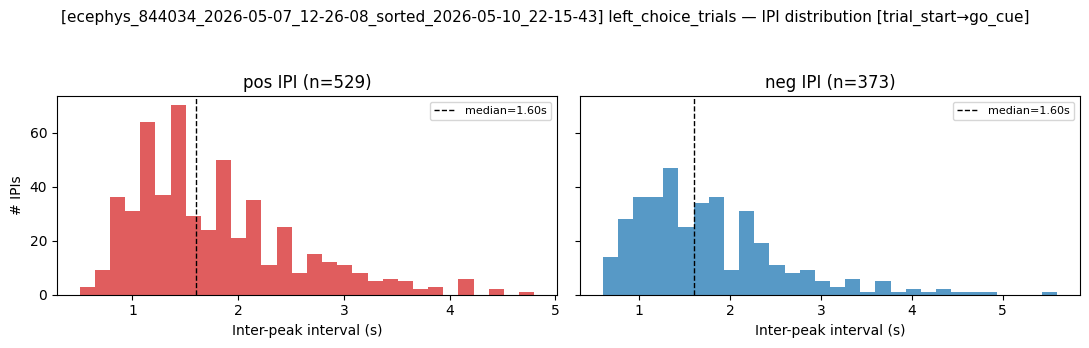


=== Session: ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45 ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-04_16-06-43.nwb

[ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45] right_choice_trials: 241/257 trials with bump in (-15, 0) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 549          -3.45         3.7        7.234182     1.765401      0.571204   0.420520     3.001439    4.047837
     pos 411          -3.25         3.6        3.948425     1.868926      0.638488   0.468208     2.641537   -3.307508


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


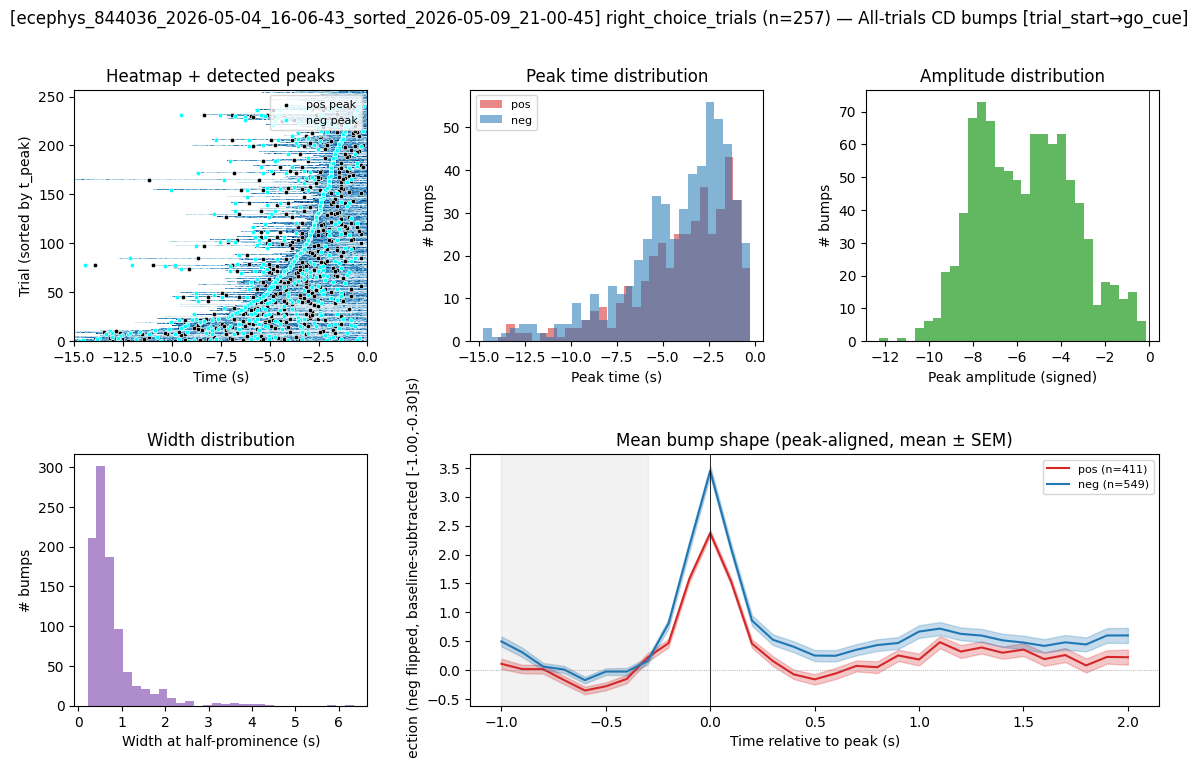

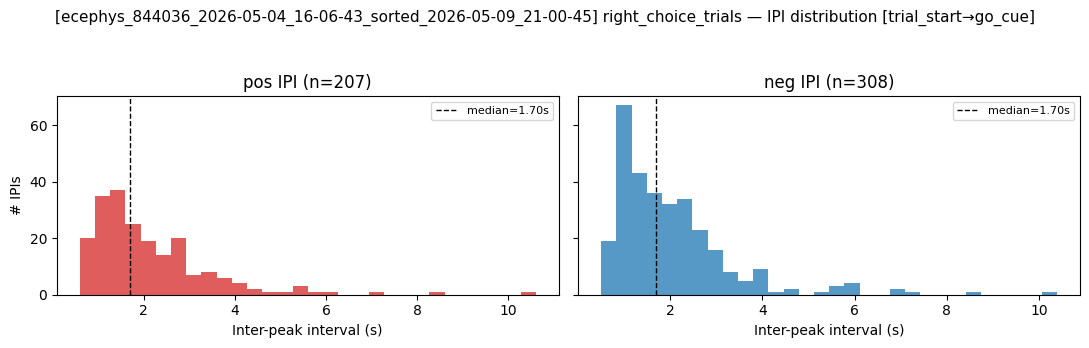


[ecephys_844036_2026-05-04_16-06-43_sorted_2026-05-09_21-00-45] left_choice_trials: 219/246 trials with bump in (-15, 0) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 422          -3.05       3.175        6.925241     2.281283      0.577648   0.439508     2.822617    3.914007
     pos 286          -2.75       2.875        3.684194     2.416964      0.638611   0.498877     2.564639   -2.968944


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


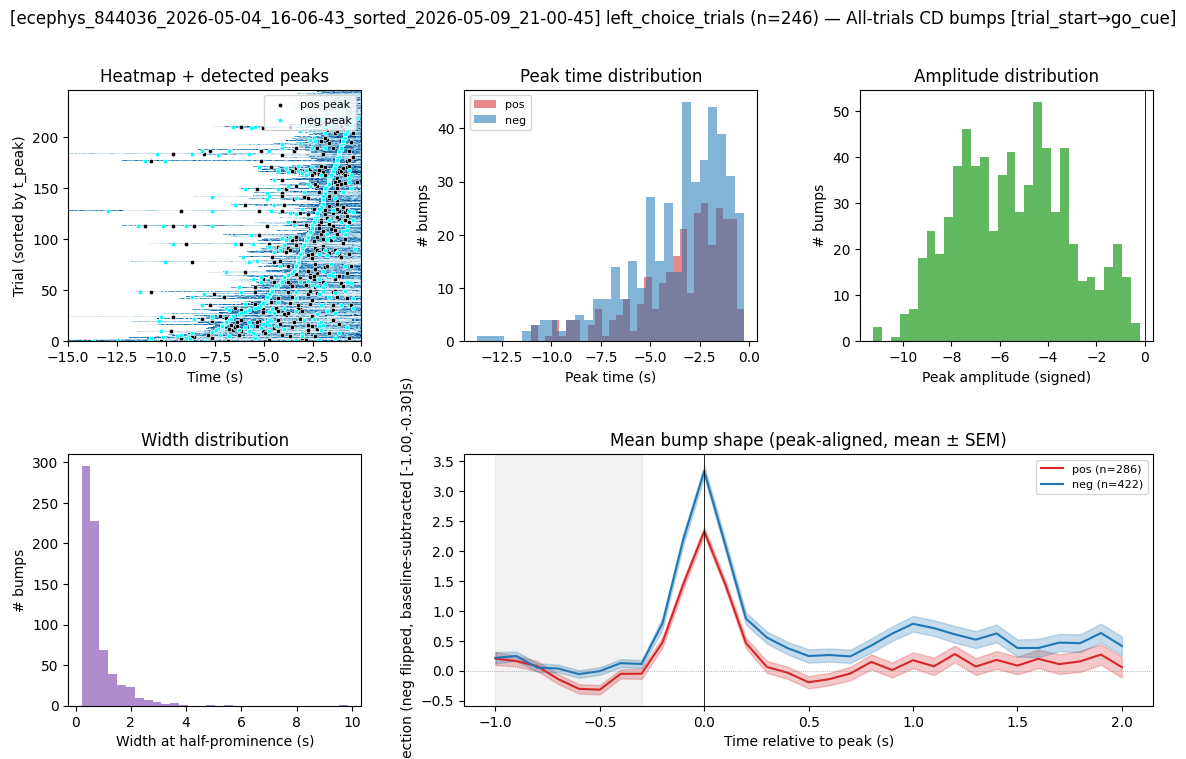

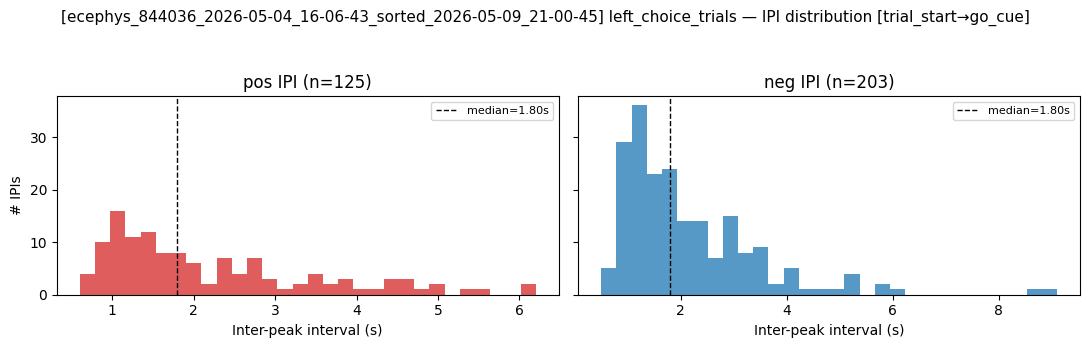


=== Session: ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51 ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-05_16-08-08.nwb

[ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51] right_choice_trials: 251/313 trials with bump in (-15, 0) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 407          -3.65        4.05        6.477769     1.825189      0.723116   0.549875     2.755364    4.426047
     pos 240          -3.35        3.75        3.722394     1.605175      0.678220   0.642442     2.473492   -2.855184


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


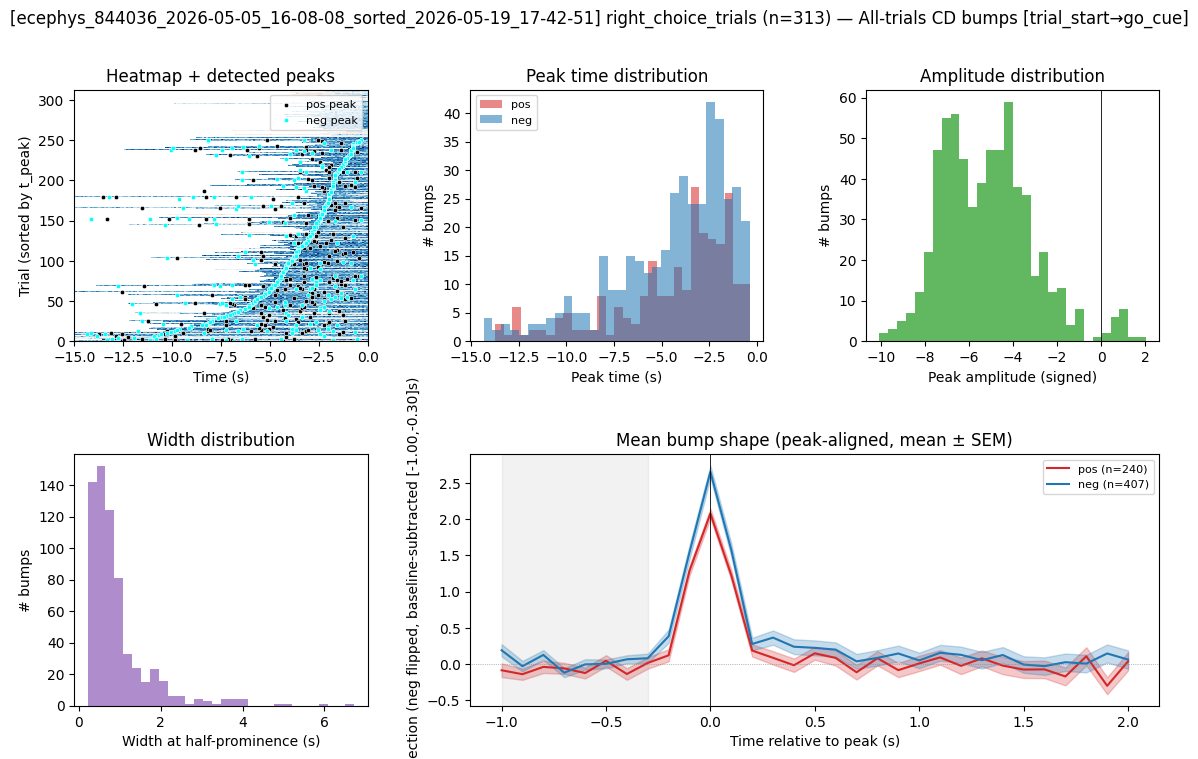

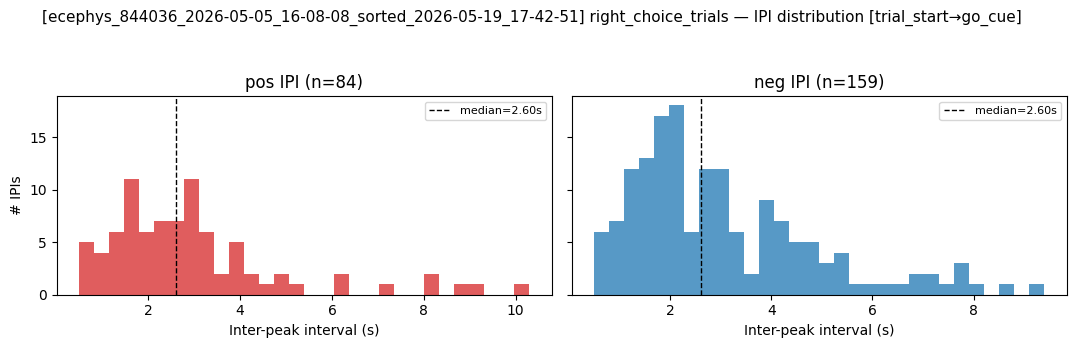


[ecephys_844036_2026-05-05_16-08-08_sorted_2026-05-19_17-42-51] left_choice_trials: 123/183 trials with bump in (-15, 0) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 190           -3.0       3.100        6.818123     1.448092      0.745490   0.718401     2.810269    4.849993
     pos 104           -2.9       3.025        4.062680     1.106055      0.636741   0.554595     2.419585   -3.008492


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


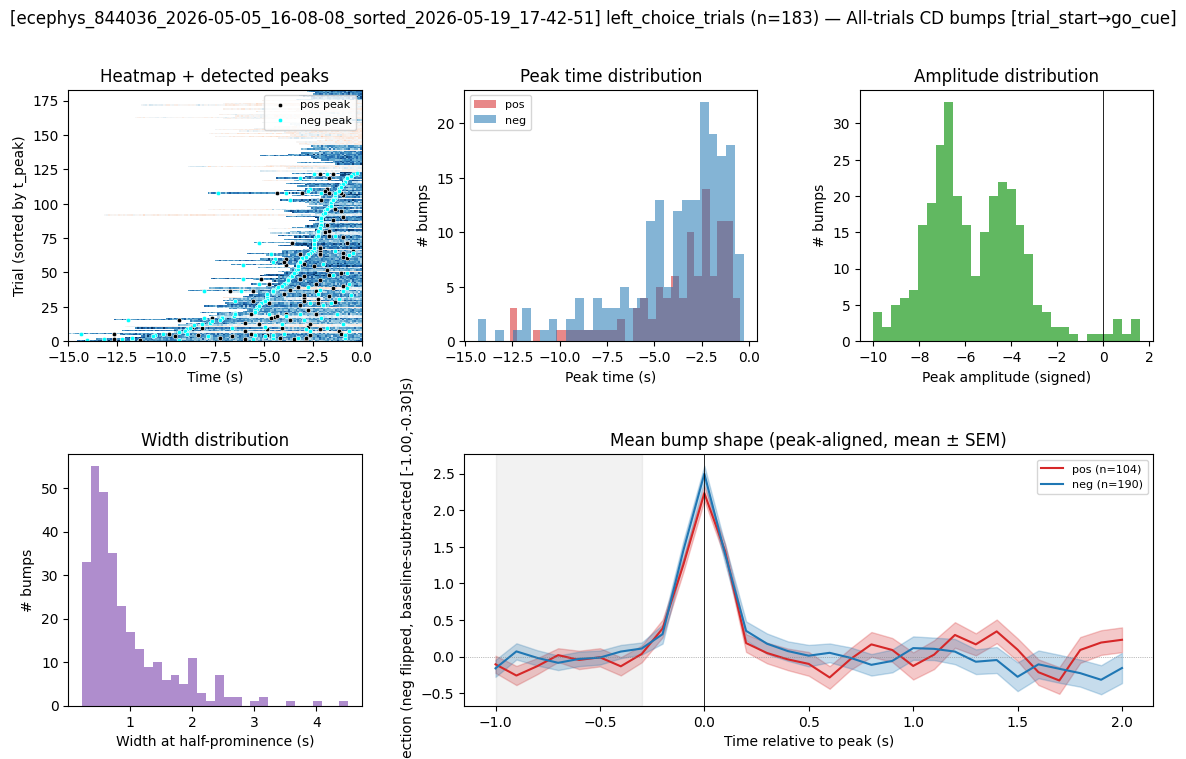

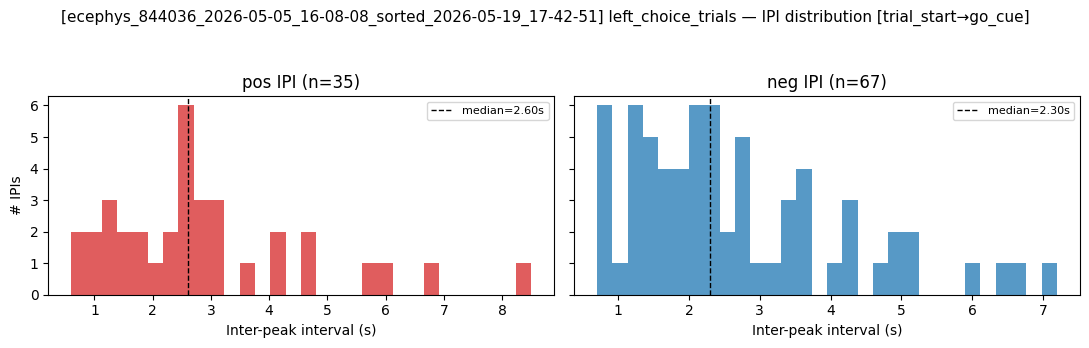


=== Session: ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13 ===
Found behavior NWB: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/844036_2026-05-06_16-27-46.nwb

[ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13] right_choice_trials: 253/271 trials with bump in (-15, 0) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 497          -2.95         3.3        2.651851     0.929012      0.586495   0.495888     2.722626   -2.362958
     pos 642          -3.05         3.4        5.878411     1.322749      0.470804   0.327470     3.050762    2.914822


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


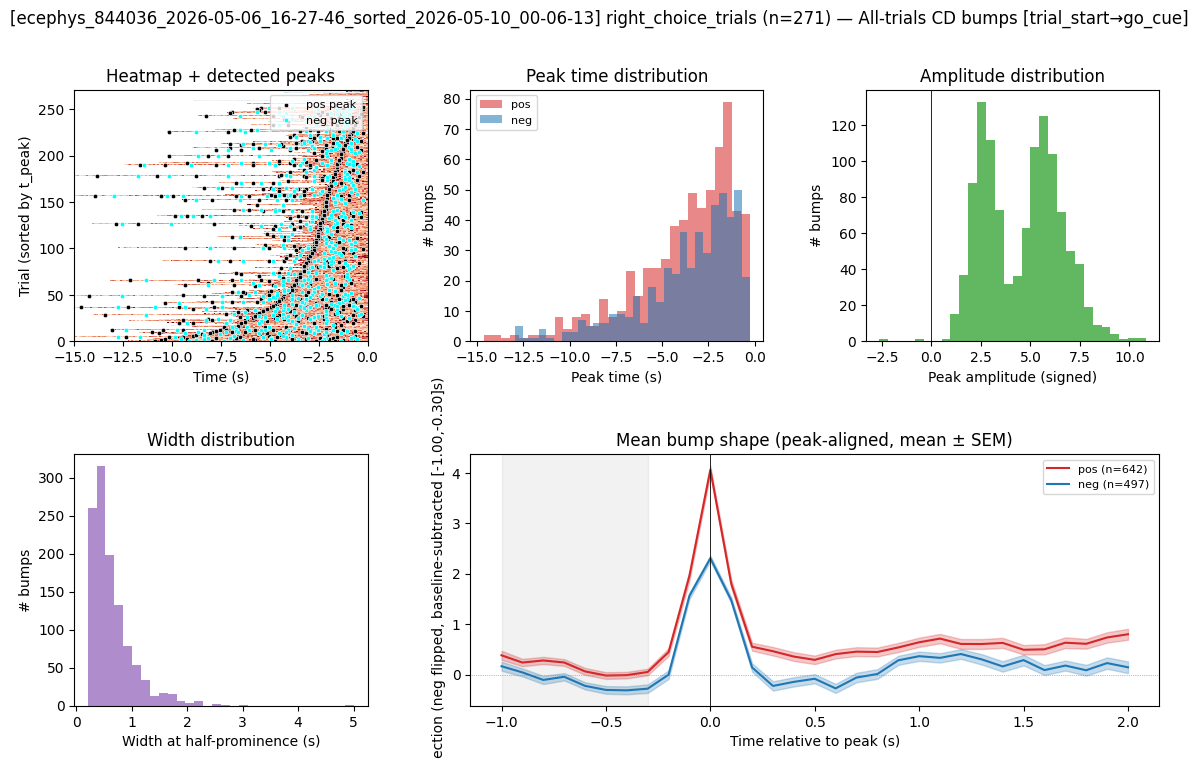

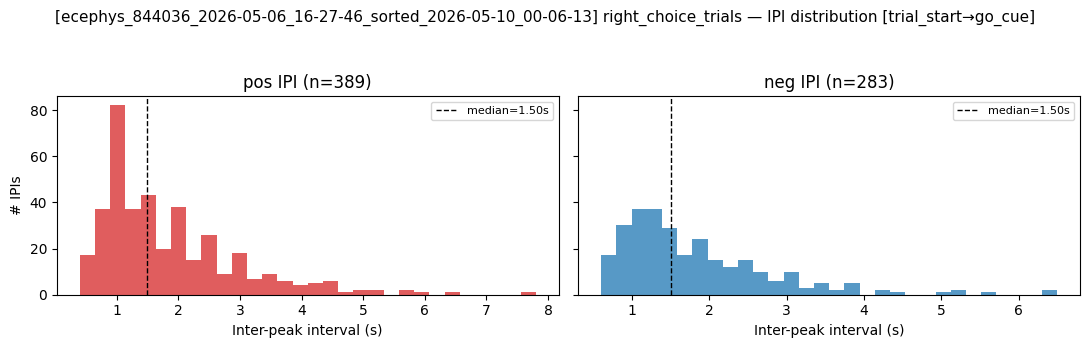


[ecephys_844036_2026-05-06_16-27-46_sorted_2026-05-10_00-06-13] left_choice_trials: 166/184 trials with bump in (-15, 0) s
polarity   n  t_peak_median  t_peak_iqr  abs_amp_median  abs_amp_iqr  width_median  width_iqr  prom_median  auc_median
     neg 295          -2.65         2.8        2.642724     0.994907      0.584305   0.491676     2.919755   -2.332835
     pos 396          -2.80         3.1        6.114700     1.250761      0.462615   0.339737     3.240327    3.008435


/root/capsule/src/aind_dft_ephys_analysis/ephys_dimension_reduction_CD_bump.py:402: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


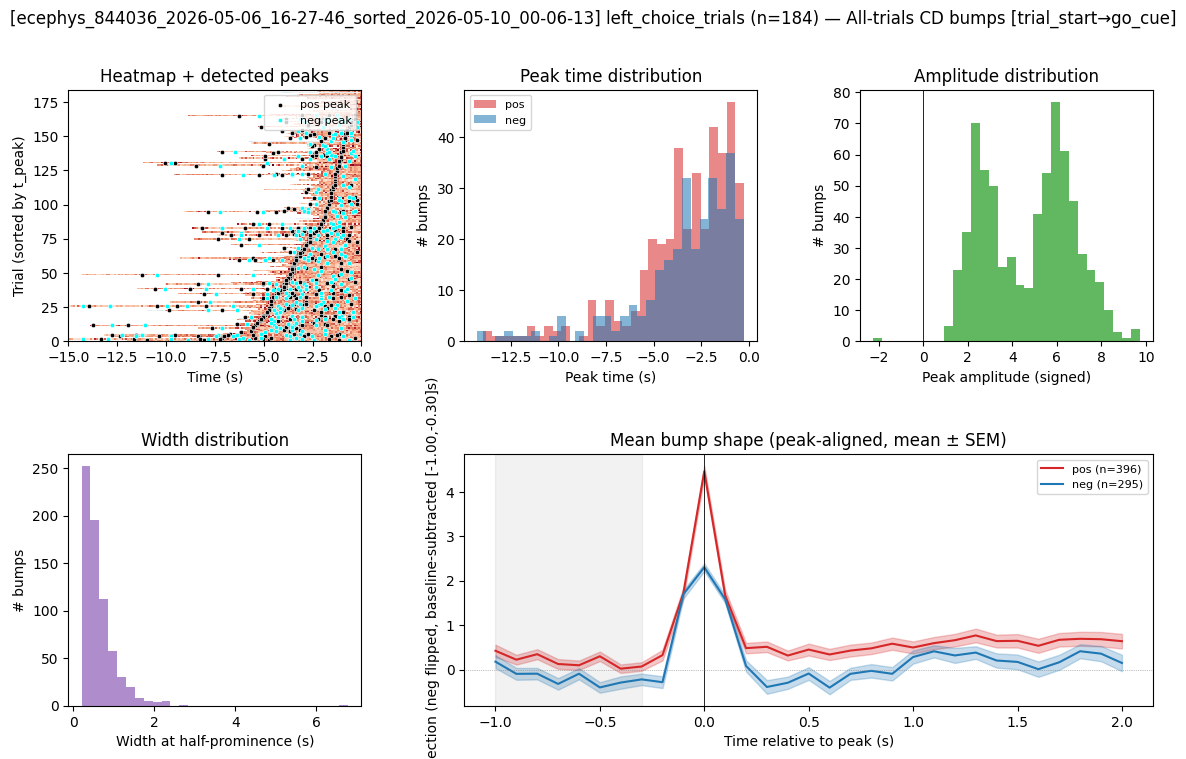

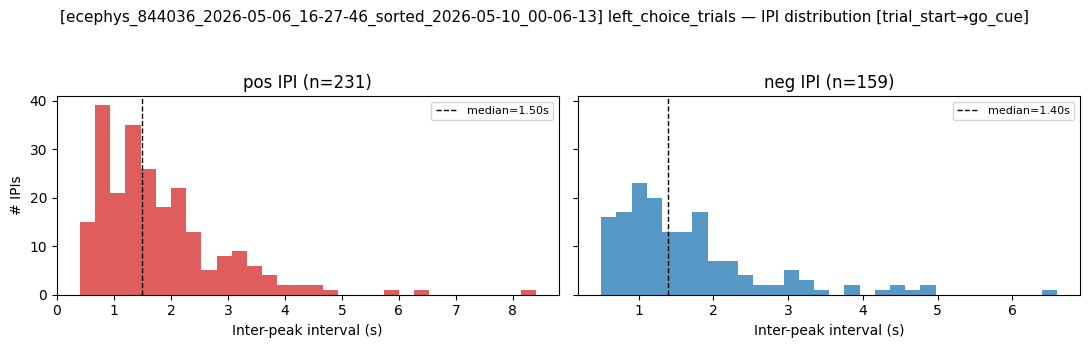

In [150]:
# =============================================================================
# Per-session BUMP DETECTION on single-trial CD projections.
# For each class, detect transient excursions of the projection, summarize
# their timing/amplitude/width statistics, and visualize.
# =============================================================================
import os

from ephys_dimension_reduction_CD_pipeline import (
    cd_save_path, load_cd_session, plot_cd_session_bumps, region_label,
)

cd_root = "/root/capsule/scratch/CD_results"
behavior_root = "/root/capsule/scratch/behavior_summary"

viz_region_group = []
viz_time_window = (-1, 0)
trial_types     = ("switch_LR_trials", "switch_RL_trials")
restrict_events = ("trial_start", "go_cue")

region_lbl, region_print = region_label(viz_region_group)
print(f"Viewing region: {region_lbl} ({region_print}), TW={viz_time_window}, align={align}")

all_bumps = {}  # session -> {class_name: DataFrame}

for session in sessions:
    zpath = cd_save_path(
        cd_root, session, region_lbl, trial_types, viz_time_window, align=align,
    )
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not zpath.exists() or not os.path.exists(beh_csv):
        print(f"[skip] missing files for {session}")
        continue

    print(f"\n=== Session: {session} ===")
    sess = load_cd_session(zpath, beh_csv)

    # Detect bumps in 0-3 s after trial_start (re-aligned per trial).
    # Allow multiple bumps per trial — top-K ranked by prominence per polarity.
    dfs = plot_cd_session_bumps(
        sess,
        restrict_events=restrict_events,
        restrict_align="go_cue",
        xlim=(-15, 0),
        search_window=(-15, 0),
        polarity="both",          # detect positive and negative excursions
        smooth_sigma_sec=0.15,
        min_prominence=2.0,       # tune to your signal scale
        min_width_sec=0.2,
        max_per_trial=500,          # up to 5 bumps per polarity per trial
        shape_window=(-1.0, 2.0),
        return_df=True,
        trial_types=["right_choice_trials", "left_choice_trials"],
    )
    if dfs:
        all_bumps[session] = dfs



In [ ]:
# =============================================================================
# Aggregate CD across the listed sessions and plot averages
# =============================================================================
import os

from ephys_dimension_reduction_CD_pipeline import (
    cd_save_path, load_cd_session, aggregate_cd_sessions, plot_cd_aggregate,
    region_label,
)

region_lbl, region_print = region_label(viz_region_group)
required_suffix = f"_{region_lbl}_"
print(f"Aggregating region: {region_lbl} ({region_print}), TW={viz_time_window}, align={align}")

sessions_data = []
for session in sessions:
    zpath = cd_save_path(
        cd_root, session, region_lbl, trial_types, viz_time_window, align=align,
    )
    beh_csv = os.path.join(behavior_root, f"behavior_summary-{session}.csv")
    if not zpath.exists():
        print(f"[skip] CD zarr not found: {zpath}")
        continue
    if not os.path.exists(beh_csv):
        print(f"[skip] behavior CSV not found for {session}")
        continue
    sessions_data.append(load_cd_session(zpath, beh_csv))

print(f"\nLoaded {len(sessions_data)} session(s) for aggregation.")
agg = aggregate_cd_sessions(sessions_data)
plot_cd_aggregate(
    agg,
    distribution_window=distribution_window,
    smooth_gauss=0.1,
)
